In [1]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.ensemble import BaggingClassifier , AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer



### Gradient Boosting Recap
- GB involves exhaustive search procedure 
- Each CART is trained to find the best split points and features
- May lead to CARTS using the same split points and maybe same features

# Stochastic Boosting
- Each tree is trained on a random subset of rows of the training data
- The sample instances (40% - 80% ) of the training set are sampled without replacement
- Features are sampled (Without replacement) when choosing split points
- Result : Further ensemble diversity
- Effect: Adding further variance to the ensmble of trees

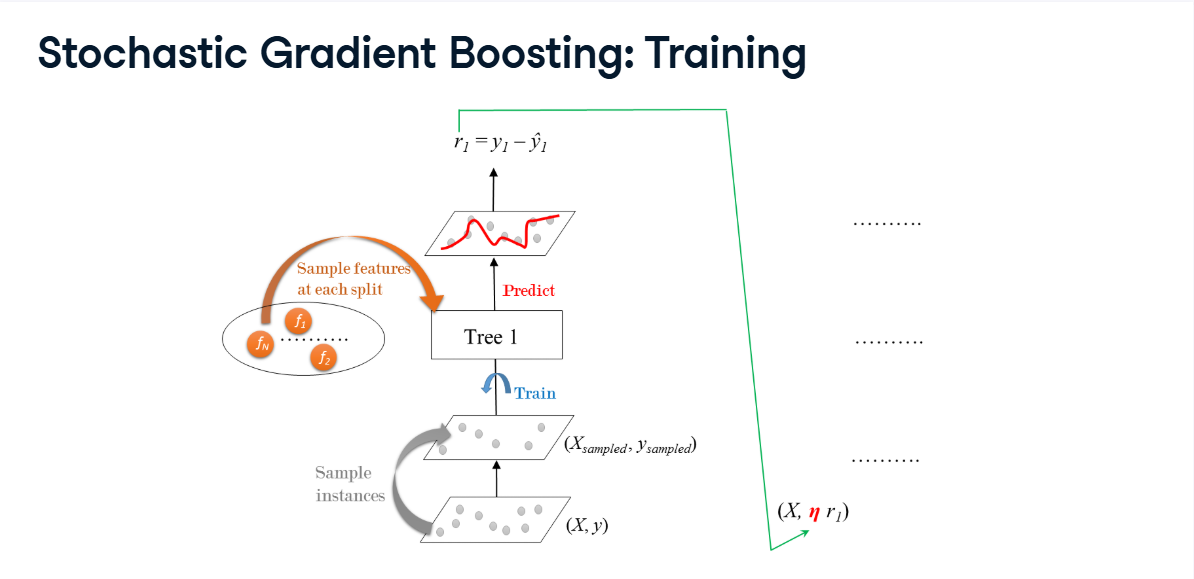

- Instead of providing all the training instances to a tree , only a fraction of these instances are provided through sampling without replacement
- The sample data is then used to for training a tree
- However not all features are considered when a split is made
- Instead only a certain randomly sampled fraction of these features are used for this purpose
- Once a tree is trained predictions are made and the residual errors can be computed 
- These residual errors are multiplied by the learning rate **η** and are fed to the next tree in the ensemble are trained
- This procedure for a new instance in stochasitc gradient boosting is similar to that of gradient boosting


In [2]:

df_csv = pd.read_csv("../../1. Classification and Regression Trees/Regression/output_data.csv")

df_csv = df_csv.drop(["car_name","model_year","origin"],axis=1)

df_csv['horsepower'] = pd.to_numeric(df_csv['horsepower'], errors='coerce')
print(df_csv.head())
print(df_csv.info())

    mpg  cylinders  displacement  horsepower  weight  acceleration
0  18.0          8         307.0       130.0  3504.0          12.0
1  15.0          8         350.0       165.0  3693.0          11.5
2  18.0          8         318.0       150.0  3436.0          11.0
3  16.0          8         304.0       150.0  3433.0          12.0
4  17.0          8         302.0       140.0  3449.0          10.5
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 18.8 KB
None


In [3]:
feature = df_csv.drop("mpg",axis=1).values
target = df_csv['mpg'].values

df_csv.info()

X_train , X_test , y_train , y_test = train_test_split(feature,target,test_size=0.3,random_state=1)

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 18.8 KB


In [5]:
sgbt = GradientBoostingRegressor(max_depth=1,subsample=0.8,max_features=0.2,n_estimators=300,random_state=1)

sgbt.fit(X_train,y_train)

y_pred = sgbt.predict(X_test)

mse_test = MSE(y_test,y_pred)

rmse_test = mse_test ** 0.5

print("Test set RMSE : {:.2f}".format(rmse_test))
print("Test set MSE : {:.2f}".format(mse_test))

Test set RMSE : 3.68
Test set MSE : 13.56
